# Bouncing Ball Hybrid Automaton

This notebook demonstrates the running of a hybrid automaton implementation for `v0.0.4` of the hybrid-automaton pythonic API framework for hybrid automaton creation as well as some evaluation of how it runs.

## Structure Initialization

Initially we retrieve the already defined pythonic `amd (automaton model definition)` definition for the hybrid autoamton. When we print it's `__str__` function we see the AMDL represenation, and when we use `__repr__` we see the .mmd file represenation of the automaton which we can use for generatation of `https://mermaid.live/` state diagrams for visual analysis of the formalized automaton.

![Cruise Control Diagram](./figures/bouncing_ball_hybrid_automaton.png)

In [16]:
import os
import numpy as np
from hybrid_automatons import bouncing_ball
from hybrid_automaton import Automaton
import matplotlib.pyplot as plt
from hybrid_automaton import RunResult 

In [17]:
ha: Automaton = bouncing_ball(gravity=-9.81, restitution=0.8)
print (ha)

Hybrid Automaton Definition:
	name: Bouncing Ball
	id: 3
	initial_mode: FLYING
	modes: [FLYING, GROUND, RESTING]
	transitions:
		FLYING --[hit_ground]--> GROUND
		GROUND --[bounce_up]--> FLYING
		GROUND --[come_to_rest]--> RESTING
	guards:
		hit_ground: [hits_ground]
		bounce_up: [bounce_possible]
		come_to_rest: [no_more_bounce]
	resets:
		hit_ground: bounce_reset
		bounce_up: <none>
		come_to_rest: stop_reset
	invariants:
		FLYING: [<none>]
		GROUND: [<none>]
		RESTING: [failing_invariant]
	continous_dynamics:
		FLYING -> flying_flow
		GROUND -> ground_flow
		RESTING -> resting_flow



In [18]:
print (f"Hybrid Automaton `.mmd` diagram: \n\n{repr(ha)}")

Hybrid Automaton `.mmd` diagram: 

stateDiagram-v2
    direction LR
    [*] --> FLYING
    FLYING --> GROUND: hit_ground
    GROUND --> FLYING: bounce_up
    GROUND --> RESTING: come_to_rest
    note right of RESTING: invariant = failing_invariant


## Automaton Runner

In [19]:
results: RunResult = await ha.activate(
    initial_continuous_state=np.array([5.0, 0.0]), 
    enable_real_time_mode=False,
    continuous_state_sampler_enabled=True,
    continuous_state_sampler_rate=100,
    enable_self_integration=True,
    delta_time=0.001,
    timeout_sec=30.0,
    output_dir = os.path.join(os.getcwd(), 'logs', 'bouncing_ball_run')    
)

>>> Starting bouncing ball
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[E

In [20]:
print (results)

Automaton Run Summary
Run ID: 20260203T125301Z_8bc5ab
Status: SUCCESS
logs directory: /home/ryan/hybrid-automaton/notebooks/logs/bouncing_ball_run

Termination:
  Code: TERMINAL_REACHED
  Message: Terminal state 'RESTING' reached
  Final State: RESTING

Execution Metrics:
  Total Runtime: 10.912s
  Total Steps: 9343
  Transitions: 50

Step Statistics:
  NORMAL: 9292
  TRANSITION: 50
  TERMINAL_REACHED: 1


## Evaluation


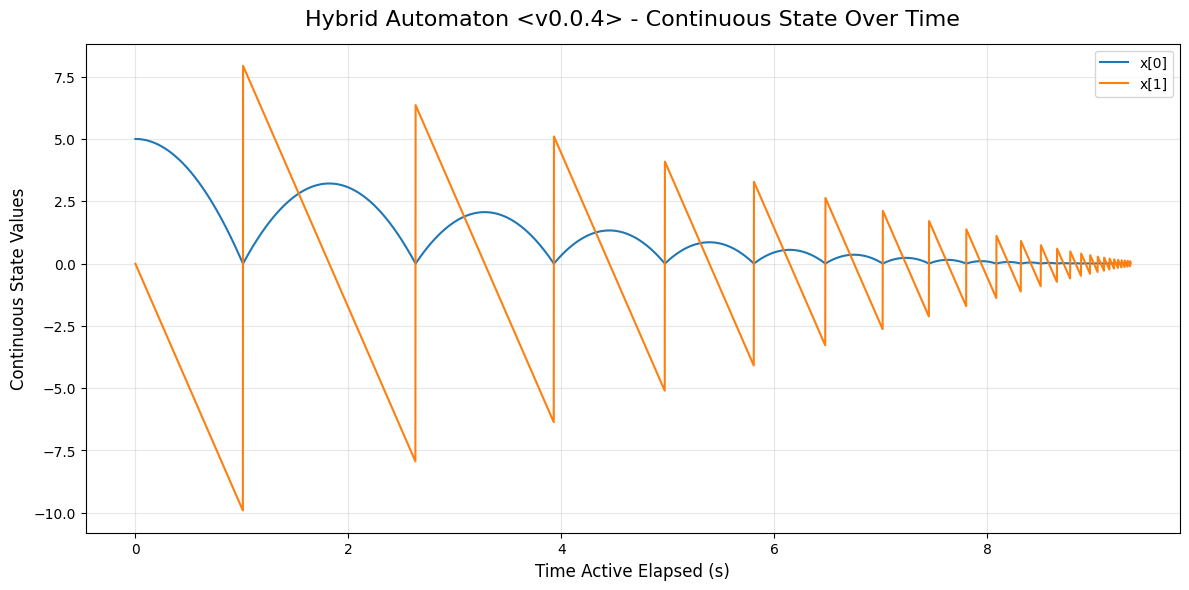

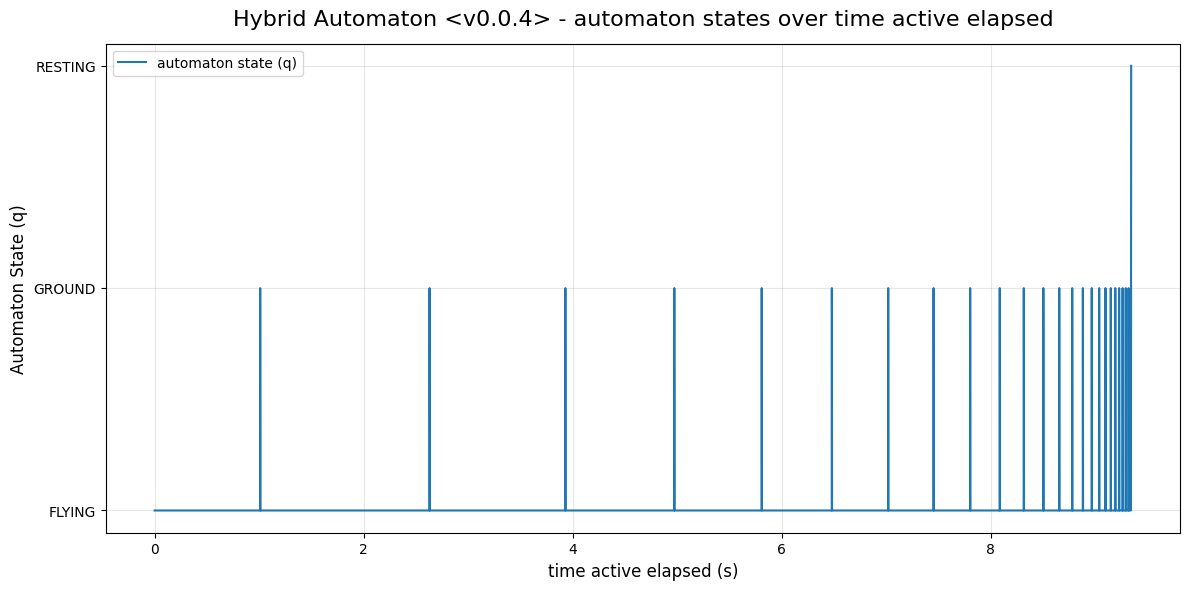

In [5]:
results = ha_runner.get_results()
fig1 = continuous_states_over_time_fig(results['continuous_states'])
# fig4 = transitions_times_over_time_fig(results['transition_times'])
fig5 = automaton_states_over_time(results['automaton_states'])
plt.show()